# Modern Temporal Learning: runnable companion

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hhsieh14/AI-courses-notes-reader/blob/main/courses/modern-temporal-learning/notebooks/mtl_companion.ipynb)

One section per chapter, from ARIMA to attention. Each section simulates or fits something from the notes, so you can see the formula and the data agree. Uses NumPy, SciPy, statsmodels, PyWavelets, scikit-learn and Matplotlib; no GPU and no deep-learning framework needed. Runs in about a minute.

| § | Chapter | What the code shows |
|---:|---|---|
| 1 | [Stationarity & ARIMA](../notes/02_classical_time_series_models.md) | AR/MA autocorrelation signatures; the ARIMA refinement loop with Ljung–Box |
| 2 | [Filters & decomposition](../notes/03_filters_smoothing_and_decomposition.md) | EWMA lags a trend by exactly $\beta_1(1-\lambda)/\lambda$; STL on Mauna Loa CO₂ |
| 3 | [Wavelets](../notes/04_wavelets.md) | Haar by hand = PyWavelets; energy preservation; threshold denoising |
| 4 | [PCA monitoring](../notes/05_pca_and_regularization.md) | a correlation-breaking fault shows up in Q but not in T² |
| 5 | [HMMs](../notes/06_markov_models_hmm_and_em.md) | scaled forward = brute force; Viterbi decoding |
| 6 | [Neural-network foundations](../notes/07_neural_network_foundations.md) | parameter counting and cross-entropy |
| 7 | [RNNs](../notes/08_rnn_lstm_gru_and_seq2seq.md) | vanishing and exploding gradients as a product of Jacobians |
| 8 | [TCNs](../notes/09_temporal_convolutional_networks.md) | receptive field of a dilated causal stack, measured with an impulse |
| 9 | [Representation learning](../notes/10_representation_learning.md) | kernel PCA untangles circles; NT-Xent and temperature |
| 10 | [Transformers](../notes/11_transformers.md) | causal attention, why $\sqrt{d_k}$, sinusoidal positions |
| 11 | [Appendix](../notes/12_handwritten_appendix.md) | differenced local level is MA(1), and EWMA with $\lambda=1-\theta$ is the best smoother |

In [1]:
import importlib, subprocess, sys
for pkg, mod in [("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib"),
                 ("scikit-learn", "sklearn"), ("statsmodels", "statsmodels"), ("PyWavelets", "pywt")]:
    if importlib.util.find_spec(mod) is None:          # e.g. on Colab, PyWavelets may be missing
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 80, "figure.figsize": (6.5, 3.6), "axes.grid": True, "grid.alpha": 0.3})

import warnings; warnings.filterwarnings("ignore")   # statsmodels convergence chatter
from statsmodels.tsa.stattools import acf, pacf

## 1. AR and MA signatures, and the ARIMA loop

AR(1) with $\phi=0.7$: ACF $=\phi^k$ decays; PACF cuts off after lag 1. MA(1) $x_t=e_t-\theta e_{t-1}$ with $\theta=0.6$: ACF is $-\theta/(1+\theta^2)$ at lag 1 and zero after.

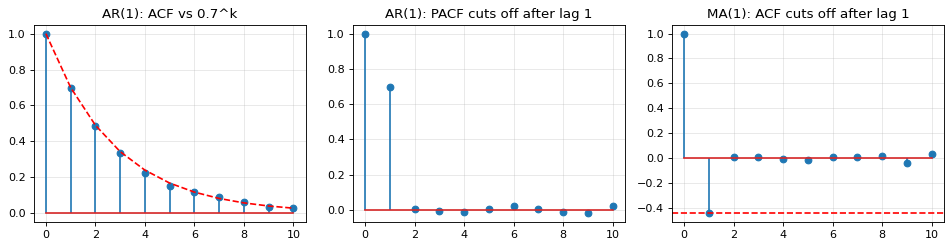

MA(1) lag-1 ACF: sample -0.446, theory -0.441


In [2]:
rng = np.random.default_rng(0); n = 5000; e = rng.normal(size=n + 1)
ar = np.zeros(n)
for t in range(1, n): ar[t] = 0.7 * ar[t - 1] + e[t]
ma = e[1:] - 0.6 * e[:-1]
lags = np.arange(11)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].stem(lags, acf(ar, nlags=10)); axes[0].plot(lags, 0.7 ** lags, "r--"); axes[0].set_title("AR(1): ACF vs 0.7^k")
axes[1].stem(lags, pacf(ar, nlags=10)); axes[1].set_title("AR(1): PACF cuts off after lag 1")
axes[2].stem(lags, acf(ma, nlags=10)); axes[2].axhline(-0.6 / 1.36, color="r", ls="--"); axes[2].set_title("MA(1): ACF cuts off after lag 1")
plt.tight_layout(); plt.show()
print(f"MA(1) lag-1 ACF: sample {acf(ma, nlags=1)[1]:.3f}, theory {-0.6/1.36:.3f}")

The refinement loop on a trending series generated as ARIMA(1,1,1): fit, check the residual autocorrelation with Ljung–Box (a large p-value means no leftover structure), and add the missing term.

In [3]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
warnings.simplefilter("ignore")
rng = np.random.default_rng(1); e = rng.normal(size=600); d = np.zeros(600)
for t in range(1, 600): d[t] = 0.2 + 0.5 * d[t - 1] + e[t] + 0.4 * e[t - 1]   # differences are ARMA(1,1) with drift
series = np.cumsum(d)
print(" order       AIC      Ljung–Box p (lag 10)")
for order in [(1, 0, 0), (1, 1, 0), (1, 1, 1)]:
    fit = ARIMA(series, order=order, trend="t" if order[1] else "c").fit()
    p = acorr_ljungbox(fit.resid[1:], lags=[10])["lb_pvalue"].iloc[0]
    print(f" {str(order):9s} {fit.aic:8.1f}   {p:.3f}")

 order       AIC      Ljung–Box p (lag 10)


 (1, 0, 0)   2054.3   0.000
 (1, 1, 0)   1686.3   0.000


 (1, 1, 1)   1642.4   0.221


## 2. EWMA lag, and STL on real data

On a noiseless line $x_t=\beta_0+\beta_1t$, the EWMA $y_t=\lambda x_t+(1-\lambda)y_{t-1}$ settles exactly $\beta_1(1-\lambda)/\lambda$ below the line. Holt's trend term exists to remove this lag.

In [4]:
beta1, lam = 2.0, 0.2; t = np.arange(300); x = 5 + beta1 * t
y = np.zeros_like(x, dtype=float); y[0] = x[0]
for i in range(1, len(x)): y[i] = lam * x[i] + (1 - lam) * y[i - 1]
print(f"steady-state lag: measured {x[-1] - y[-1]:.4f}, formula β1(1−λ)/λ = {beta1 * (1 - lam) / lam:.4f}")

steady-state lag: measured 8.0000, formula β1(1−λ)/λ = 8.0000


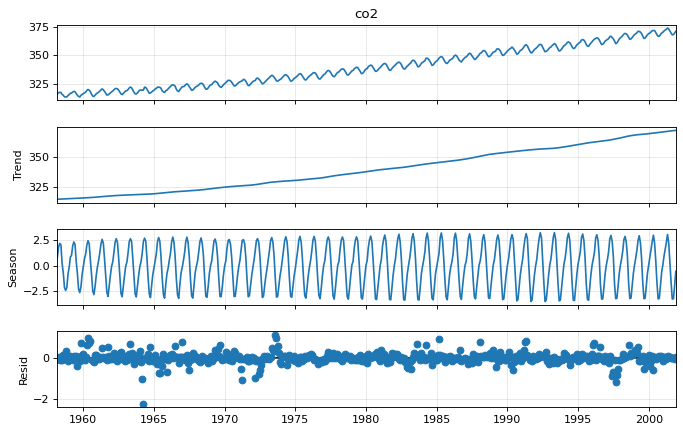

seasonal amplitude ≈ 6.7 ppm;  trend rose 56.2 ppm from 1958 to 2001


In [5]:
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
co2 = sm.datasets.co2.load_pandas().data["co2"].resample("MS").mean().ffill()
res = STL(co2, period=12, robust=True).fit()
fig = res.plot(); fig.set_size_inches(9, 6); plt.show()
print(f"seasonal amplitude ≈ {res.seasonal[-120:].max() - res.seasonal[-120:].min():.1f} ppm;  "
      f"trend rose {res.trend.iloc[-1] - res.trend.iloc[0]:.1f} ppm from {co2.index[0].year} to {co2.index[-1].year}")

## 3. Wavelets

One Haar level is $a=(x_{2i}+x_{2i+1})/\sqrt2$, $d=(x_{2i}-x_{2i+1})/\sqrt2$. It matches PyWavelets, preserves energy, and soft thresholding at $\hat\sigma\sqrt{2\log N}$ removes noise while keeping the jumps sharp.

by hand   : [ 2.828  8.485 16.971 25.456] [-1.414 -1.414 -1.414 -1.414]
PyWavelets: [ 2.828  8.485 16.971 25.456] [-1.414 -1.414 -1.414 -1.414]
energy preserved: True
estimated σ = 0.557 (true 0.6);  RMSE noisy 0.584 → denoised 0.329


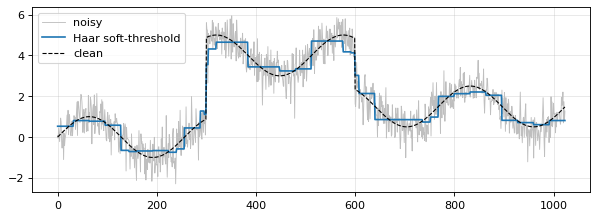

In [6]:
import pywt
x = np.array([1., 3., 5., 7., 11., 13., 17., 19.])
a, d = (x[0::2] + x[1::2]) / np.sqrt(2), (x[0::2] - x[1::2]) / np.sqrt(2)
cA, cD = pywt.dwt(x, "haar")
print("by hand   :", a.round(3), d.round(3))
print("PyWavelets:", cA.round(3), cD.round(3))
print("energy preserved:", np.isclose((x**2).sum(), (a**2).sum() + (d**2).sum()))

rng = np.random.default_rng(0); N = 1024; tt = np.arange(N)
clean = np.piecewise(tt.astype(float), [tt < 300, (tt >= 300) & (tt < 600), tt >= 600], [0, 4, 1.5]) + np.sin(2 * np.pi * tt / 256)
noisy = clean + rng.normal(0, 0.6, N)
coeffs = pywt.wavedec(noisy, "haar", level=6)
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
thr = sigma * np.sqrt(2 * np.log(N))
den = pywt.waverec([coeffs[0]] + [pywt.threshold(c, thr, "soft") for c in coeffs[1:]], "haar")
print(f"estimated σ = {sigma:.3f} (true 0.6);  RMSE noisy {np.sqrt(np.mean((noisy-clean)**2)):.3f} → denoised {np.sqrt(np.mean((den-clean)**2)):.3f}")
plt.figure(figsize=(9, 3)); plt.plot(noisy, color="0.75", lw=0.8, label="noisy"); plt.plot(den, label="Haar soft-threshold"); plt.plot(clean, "k--", lw=1, label="clean")
plt.legend(); plt.show()

## 4. PCA monitoring: T² vs Q

Six sensors driven by two latent factors. Two faults are injected: one pushes the process *along* its normal correlation structure (large $T^2$), the other *breaks* the correlation (large $Q$, the squared residual off the PCA subspace).

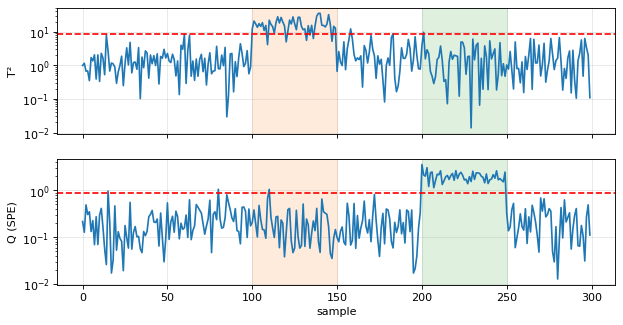

fault A (along the structure): T² alarms 88%, Q alarms 2%
fault B (breaks correlation) : T² alarms 2%, Q alarms 100%


In [7]:
rng = np.random.default_rng(0)
Lmat = rng.normal(size=(2, 6)); train = rng.normal(size=(1000, 2)) @ Lmat + 0.2 * rng.normal(size=(1000, 6))
mu, sd = train.mean(0), train.std(0); Z = (train - mu) / sd
U, S, Vt = np.linalg.svd(Z, full_matrices=False); V = Vt[:2].T; lam = S[:2]**2 / (len(Z) - 1)
def stats(X):
    z = (X - mu) / sd; s = z @ V
    return (s**2 / lam).sum(1), ((z - s @ V.T) ** 2).sum(1)
T2_lim, Q_lim = [np.quantile(v, 0.99) for v in stats(train)]
test = rng.normal(size=(300, 2)) @ Lmat + 0.2 * rng.normal(size=(300, 6))
test[100:150] += 4 * Lmat[0]                     # fault A: big move along a normal direction
test[200:250, 3] += 2.0                          # fault B: one sensor drifts alone
T2, Q = stats(test)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
a1.plot(T2); a1.axhline(T2_lim, color="r", ls="--"); a1.set_ylabel("T²"); a1.set_yscale("log")
a2.plot(Q); a2.axhline(Q_lim, color="r", ls="--"); a2.set_ylabel("Q (SPE)"); a2.set_yscale("log"); a2.set_xlabel("sample")
for ax in (a1, a2): ax.axvspan(100, 150, color="C1", alpha=0.15); ax.axvspan(200, 250, color="C2", alpha=0.15)
plt.show()
print(f"fault A (along the structure): T² alarms {np.mean(T2[100:150] > T2_lim):.0%}, Q alarms {np.mean(Q[100:150] > Q_lim):.0%}")
print(f"fault B (breaks correlation) : T² alarms {np.mean(T2[200:250] > T2_lim):.0%}, Q alarms {np.mean(Q[200:250] > Q_lim):.0%}")

## 5. Hidden Markov models: forward and Viterbi

Two hidden states with Gaussian emissions. The scaled forward algorithm matches brute-force summation over all $Q^T$ paths on a short sequence. Viterbi recovers the hidden path on a long one.

log P(y), T=6:  forward -11.248054   brute force over 2^6 paths -11.248054
T=500: Viterbi accuracy 0.958  vs  thresholding each point alone 0.874


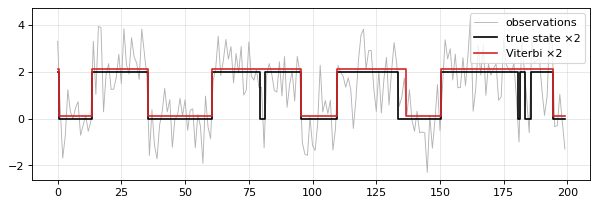

In [8]:
from itertools import product
from scipy.stats import norm
A = np.array([[0.95, 0.05], [0.10, 0.90]]); pi0 = np.array([0.5, 0.5]); means, sds = np.array([0.0, 2.0]), np.array([1.0, 1.0])
F = lambda y: norm.pdf(y[:, None], means, sds)                       # (T, Q) emission likelihoods
def forward_loglik(y):
    B = F(y); alpha = pi0 * B[0]; c = alpha.sum(); alpha /= c; ll = np.log(c)
    for t in range(1, len(y)):
        alpha = (alpha @ A) * B[t]; c = alpha.sum(); alpha /= c; ll += np.log(c)
    return ll
def viterbi(y):
    lB, lA = np.log(F(y)), np.log(A); delta = np.log(pi0) + lB[0]; psi = []
    for t in range(1, len(y)):
        cand = delta[:, None] + lA; psi.append(cand.argmax(0)); delta = cand.max(0) + lB[t]
    path = [int(delta.argmax())]
    for p_ in reversed(psi): path.append(int(p_[path[-1]]))
    return np.array(path[::-1])
def simulate(T, rng):
    s = [rng.choice(2, p=pi0)]
    for _ in range(T - 1): s.append(rng.choice(2, p=A[s[-1]]))
    s = np.array(s); return s, rng.normal(means[s], sds[s])
rng = np.random.default_rng(0)
_, y6 = simulate(6, rng)
brute = sum(pi0[p[0]] * np.prod([A[p[t-1], p[t]] for t in range(1, 6)]) * np.prod(F(y6)[np.arange(6), list(p)]) for p in product([0, 1], repeat=6))
print(f"log P(y), T=6:  forward {forward_loglik(y6):.6f}   brute force over 2^6 paths {np.log(brute):.6f}")
states, y = simulate(500, rng)
path = viterbi(y); naive = (y > 1.0).astype(int)
print(f"T=500: Viterbi accuracy {np.mean(path == states):.3f}  vs  thresholding each point alone {np.mean(naive == states):.3f}")
plt.figure(figsize=(9, 2.8)); plt.plot(y[:200], color="0.7", lw=0.8, label="observations")
plt.step(range(200), 2 * states[:200], "k", where="mid", label="true state ×2"); plt.step(range(200), 2 * path[:200] + 0.1, "C3", where="mid", label="Viterbi ×2")
plt.legend(loc="upper right"); plt.show()

## 6. Parameter counting and cross-entropy

The worked example from Chapter 7: 70 or 80 inputs, depending on dummy vs one-hot encoding of the 10 three-level predictors, hidden widths (20, 20, 10), 4 classes.

In [9]:
n_params = lambda widths: sum(a * b + b for a, b in zip(widths, widths[1:]))
print("dummy coding (70 inputs):", n_params([70, 20, 20, 10, 4]), "   one-hot (80 inputs):", n_params([80, 20, 20, 10, 4]))
p = np.array([0.4, 0.3, 0.2, 0.1]); y = np.array([0, 0, 0, 1])
print(f"cross-entropy for a green example: {-np.sum(y * np.log(p)):.4f} nats  (= −log 0.1)")

dummy coding (70 inputs): 2094    one-hot (80 inputs): 2294
cross-entropy for a green example: 2.3026 nats  (= −log 0.1)


## 7. Why RNN gradients vanish or explode

The gradient from step $k$ to step $t$ carries the product $\prod_j\mathrm{diag}(\phi'(a_j))\,U$. Its norm shrinks or grows geometrically depending on the spectral radius of $U$.

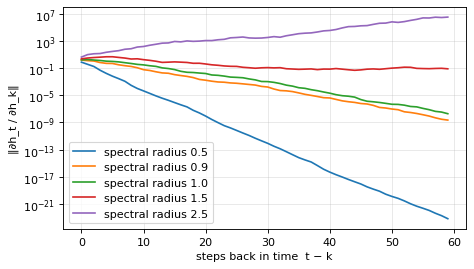

Radius ≤ 1 vanishes geometrically (tanh' ≤ 1 shrinks it further, so even radius 1.0 vanishes); radius 2.5 explodes.
Saturation damps growth, so the boundary between vanishing and exploding sits somewhat above 1.


In [10]:
rng = np.random.default_rng(0); h_dim, T = 32, 60
fig = plt.figure()
for rho in (0.5, 0.9, 1.0, 1.5, 2.5):
    U = rng.normal(size=(h_dim, h_dim)); U *= rho / np.abs(np.linalg.eigvals(U)).max()
    W = rng.normal(size=(h_dim, 1)) * 0.5; h = np.zeros(h_dim); J = np.eye(h_dim); norms = []
    for t in range(T):
        a = U @ h + (W @ rng.normal(size=1)); h = np.tanh(a)
        J = np.diag(1 - h**2) @ U @ J; norms.append(np.linalg.norm(J, 2))
    plt.semilogy(norms, label=f"spectral radius {rho}")
plt.xlabel("steps back in time  t − k"); plt.ylabel("‖∂h_t / ∂h_k‖"); plt.legend(); plt.show()
print("Radius ≤ 1 vanishes geometrically (tanh' ≤ 1 shrinks it further, so even radius 1.0 vanishes); radius 2.5 explodes.")
print("Saturation damps growth, so the boundary between vanishing and exploding sits somewhat above 1.")

## 8. Receptive field of a dilated causal stack

Push a unit impulse at $t=0$ through stacked causal convolutions and see how far it reaches. For kernel $k$ and dilations $d_\ell$ the reach is $1+(k-1)\sum_\ell d_\ell$.

In [11]:
def causal_conv(x, k, d):
    xp = np.r_[np.zeros((k - 1) * d), x]
    return np.array([sum(xp[(k - 1) * d + t - i * d] for i in range(k)) for t in range(len(x))])
def reach(k, dilations, T=4000):
    h = np.zeros(T); h[0] = 1.0
    for d in dilations: h = causal_conv(h, k, d)
    return int(np.nonzero(h)[0].max()) + 1
for k, dil in [(3, [1, 1, 1, 1]), (3, [1, 2, 4, 8]), (2, [2**i for i in range(10)])]:
    print(f"k={k}, dilations {dil}: measured {reach(k, dil)}, formula {1 + (k - 1) * sum(dil)}")

k=3, dilations [1, 1, 1, 1]: measured 9, formula 9
k=3, dilations [1, 2, 4, 8]: measured 31, formula 31
k=2, dilations [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]: measured 1024, formula 1024


## 9. Representation learning

**Kernel PCA.** Two concentric circles can't be separated by any linear projection. With a degree-2 polynomial kernel the feature space contains $x_1^2$ and $x_2^2$, so the radius becomes a *linear* direction there, and one kernel component separates the circles perfectly. Note it's the **third** component, not the first: components are ordered by variance, not by usefulness for your task.

best threshold accuracy on each linear PC : [0.67, 0.672]


best threshold accuracy on each kernel PC : [0.72, 0.715, 1.0]


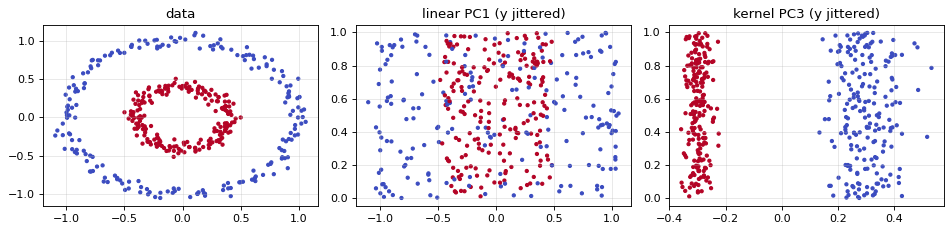

In [12]:
from sklearn.datasets import make_circles
from sklearn.decomposition import PCA, KernelPCA
Xc, yc = make_circles(400, factor=0.4, noise=0.05, random_state=0)
sep = lambda z: max(max(np.mean((z > th) == yc), np.mean((z <= th) == yc)) for th in np.unique(z))   # best 1-D threshold
lin = PCA(2).fit_transform(Xc); ker = KernelPCA(3, kernel="poly", degree=2, gamma=1, coef0=0).fit_transform(Xc)
print("best threshold accuracy on each linear PC :", [round(float(sep(lin[:, j])), 3) for j in range(2)])
print("best threshold accuracy on each kernel PC :", [round(float(sep(ker[:, j])), 3) for j in range(3)])
rng = np.random.default_rng(0); jit = rng.uniform(size=400)
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].scatter(*Xc.T, c=yc, cmap="coolwarm", s=8); axes[0].set_title("data")
axes[1].scatter(lin[:, 0], jit, c=yc, cmap="coolwarm", s=8); axes[1].set_title("linear PC1 (y jittered)")
axes[2].scatter(ker[:, 2], jit, c=yc, cmap="coolwarm", s=8); axes[2].set_title("kernel PC3 (y jittered)")
plt.tight_layout(); plt.show()

**NT-Xent and temperature.** Matched views score far below chance, $\log(2K-1)$. A lower temperature sharpens the softmax over similarities.

In [13]:
def nt_xent(z, tau=0.5):
    z = z / np.linalg.norm(z, axis=1, keepdims=True); s = z @ z.T / tau; np.fill_diagonal(s, -np.inf)
    pos = np.arange(len(z)) ^ 1
    return -(s[np.arange(len(z)), pos] - np.log(np.exp(s).sum(1))).mean()
rng = np.random.default_rng(0); base = rng.normal(size=(4, 8))
views = np.repeat(base, 2, axis=0) + 0.05 * rng.normal(size=(8, 8))
print(f"NT-Xent: matched views {nt_xent(views):.3f}   random vectors {nt_xent(rng.normal(size=(8, 8))):.3f}   chance log(7) = {np.log(7):.3f}")
s = np.array([2.3, 1.6, -1.2])
for tau in (0.1, 0.5, 1, 10):
    p = np.exp(s / tau); print(f"τ = {tau:<4}: softmax = {np.round(p / p.sum(), 3)}")

NT-Xent: matched views 0.621   random vectors 2.158   chance log(7) = 1.946
τ = 0.1 : softmax = [0.999 0.001 0.   ]
τ = 0.5 : softmax = [0.802 0.198 0.001]
τ = 1   : softmax = [0.655 0.325 0.02 ]
τ = 10  : softmax = [0.379 0.354 0.267]


## 10. Attention

Causal scaled dot-product attention: each row of weights sums to 1 and puts no weight on the future. Without the $\sqrt{d_k}$ scaling, score spread grows like $\sqrt{d_k}$ and the softmax saturates. Sinusoidal encodings give each position a unique multi-frequency code.

row sums: [1. 1. 1. 1. 1. 1.]   max weight on a future position: 0.0
d_k=  8: std of q·k =   2.9 → 1.01 after /√d_k;   avg largest weight over 10 keys: unscaled 0.66, scaled 0.34
d_k= 64: std of q·k =   8.0 → 1.00 after /√d_k;   avg largest weight over 10 keys: unscaled 0.87, scaled 0.32


d_k=512: std of q·k =  22.6 → 1.00 after /√d_k;   avg largest weight over 10 keys: unscaled 0.95, scaled 0.32


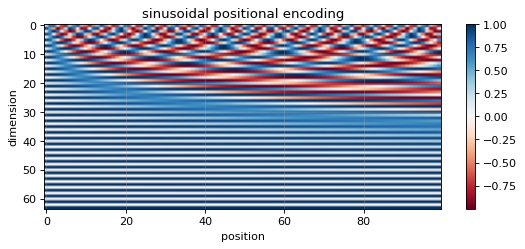

In [14]:
def attention(Q, K, V, causal=False):
    S = Q @ K.T / np.sqrt(Q.shape[-1])
    if causal: S = np.where(np.tril(np.ones_like(S)) == 1, S, -np.inf)
    W = np.exp(S - S.max(1, keepdims=True)); W /= W.sum(1, keepdims=True)
    return W @ V, W
rng = np.random.default_rng(0); T, dm, dk = 6, 16, 8
X = rng.normal(size=(T, dm)); WQ, WK, WV = (rng.normal(size=(dm, dk)) / np.sqrt(dm) for _ in range(3))
_, W = attention(X @ WQ, X @ WK, X @ WV, causal=True)
print("row sums:", W.sum(1).round(6), "  max weight on a future position:", np.triu(W, 1).max())
for d in (8, 64, 512):
    q, k = rng.normal(size=(20000, d)), rng.normal(size=(20000, d)); s = (q * k).sum(1)
    def max_w(sc): e_ = np.exp(sc.reshape(-1, 10) - sc.reshape(-1, 10).max(1, keepdims=True)); return (e_ / e_.sum(1, keepdims=True)).max(1).mean()
    print(f"d_k={d:3d}: std of q·k = {s.std():5.1f} → {(s/np.sqrt(d)).std():.2f} after /√d_k;   avg largest weight over 10 keys: unscaled {max_w(s):.2f}, scaled {max_w(s/np.sqrt(d)):.2f}")
pos, dmodel = np.arange(100)[:, None], 64; i = np.arange(dmodel // 2)[None]
PE = np.zeros((100, dmodel)); PE[:, 0::2] = np.sin(pos / 10000 ** (2 * i / dmodel)); PE[:, 1::2] = np.cos(pos / 10000 ** (2 * i / dmodel))
plt.figure(figsize=(8, 3)); plt.imshow(PE.T, aspect="auto", cmap="RdBu"); plt.xlabel("position"); plt.ylabel("dimension"); plt.title("sinusoidal positional encoding"); plt.colorbar(); plt.show()

## 11. Appendix: the differenced local level, and why EWMA is optimal

Simulate $x_t=\mu_t+e_t$ with a random-walk level. The first difference has $\rho_1=-\sigma_e^2/(\sigma_\delta^2+2\sigma_e^2)$ and nothing after lag 1, so it's MA(1) with $\theta=\frac{(q+2)-\sqrt{q^2+4q}}2$, $q=\sigma_\delta^2/\sigma_e^2$. The EWMA with weight $\lambda=1-\theta$ should give the best one-step forecasts.

lag-1 ACF of the difference: sample -0.4464, theory -0.4444;  lag 2: 0.0026
θ = 0.6096  →  predicted best EWMA weight λ = 1 − θ = 0.3904


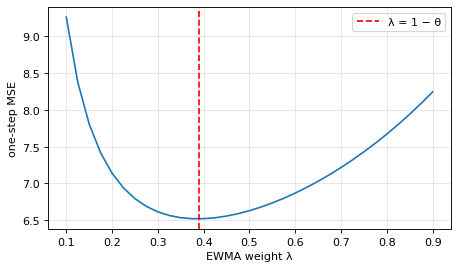

empirically best λ on the grid (step 0.025): 0.375


In [15]:
rng = np.random.default_rng(1); n, s_d, s_e = 200_000, 1.0, 2.0
x = np.cumsum(rng.normal(0, s_d, n)) + rng.normal(0, s_e, n); d = np.diff(x)
r = lambda k: np.corrcoef(d[:-k], d[k:])[0, 1]
q = s_d**2 / s_e**2; theta = ((q + 2) - np.sqrt(q * q + 4 * q)) / 2
print(f"lag-1 ACF of the difference: sample {r(1):.4f}, theory {-s_e**2 / (s_d**2 + 2 * s_e**2):.4f};  lag 2: {r(2):.4f}")
print(f"θ = {theta:.4f}  →  predicted best EWMA weight λ = 1 − θ = {1 - theta:.4f}")
def ewma_mse(lam):
    y, err = x[0], 0.0
    for v in x[1:50_001]: err += (v - y) ** 2; y = lam * v + (1 - lam) * y
    return err / 50_000
grid = np.linspace(0.1, 0.9, 33); mse = [ewma_mse(l) for l in grid]
plt.plot(grid, mse); plt.axvline(1 - theta, color="r", ls="--", label="λ = 1 − θ"); plt.xlabel("EWMA weight λ"); plt.ylabel("one-step MSE"); plt.legend(); plt.show()
print(f"empirically best λ on the grid (step 0.025): {grid[int(np.argmin(mse))]:.3f}")